In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Added OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer # Added ColumnTransformer

# Regression Models
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

df = pd.read_csv("/content/cveda_z_smith10.csv")

y = df["age"]

# 'sex' is removed from confounds to be used as a feature
confounds = ["age", "site", "mean_FD","sub_id"]      # Feature engineering
X = df.drop(columns=confounds)

# Define categorical and numerical features for preprocessing
categorical_features = ['sex'] # Assuming 'sex' is the only categorical feature
numerical_features = X.drop(columns=categorical_features).columns.tolist()

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keeps any other columns not specified (if any)
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200),
    "Support Vector Regression": SVR(kernel="rbf"),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor), # Use the column transformer here
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "R2 Score"]
).sort_values("MAE")

print("\nModel Performance Comparison:\n")
print(results_df)


Model Performance Comparison:

                       Model       MAE  R2 Score
6  Support Vector Regression  3.346884  0.078048
1           Ridge Regression  3.370968  0.076897
0          Linear Regression  3.371012  0.076743
3                Elastic Net  3.373637  0.078040
2           Lasso Regression  3.376675  0.078102
4              Random Forest  3.400345  0.064082
7                    XGBoost  3.527874  0.015298
5          Gradient Boosting  3.543261 -0.019198


**With ANN (1 Layer)..**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


# Load Data
df = pd.read_csv("/content/cveda_z_smith10.csv")

y = df["age"]

confounds = ["age", "site", "mean_FD", "sub_id"]
X = df.drop(columns=confounds)

# Preprocessing
categorical_features = ['sex']
numerical_features = X.drop(columns=categorical_features).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()


# ANN MODEL (1 Hidden Layer Only)
model_ann1 = Sequential([
    Input(shape=(X_train_processed.shape[1],)),

    Dense(
        32,
        activation='relu',
        kernel_regularizer=l2(0.001)   # Regularization
    ),

    Dropout(0.25),

    Dense(1)
])


# Compile
model_ann1.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',      # better training stability
    metrics=['mae']
)


# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)


# Train
history = model_ann1.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


# Predict
y_pred_ann1 = model_ann1.predict(X_test_processed).flatten()


# Metrics
mae = mean_absolute_error(y_test, y_pred_ann1)
r2 = r2_score(y_test, y_pred_ann1)

print("\nANN Model Performance:")
print("MAE:", mae)
print("R2 Score:", r2)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - loss: 279.9288 - mae: 16.0932 - val_loss: 266.6837 - val_mae: 15.6376
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 274.0019 - mae: 15.9102 - val_loss: 260.4241 - val_mae: 15.4421
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 267.1494 - mae: 15.7138 - val_loss: 254.3396 - val_mae: 15.2485
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 261.6530 - mae: 15.5252 - val_loss: 248.4998 - val_mae: 15.0600
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 255.7689 - mae: 15.3433 - val_loss: 242.8036 - val_mae: 14.8743
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 249.9626 - mae: 15.1469 - val_loss: 237.1715 - val_mae: 14.6879
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 244.8604 - mae: 14.9819 - val_loss: 231.6944 - val_mae: 14.5035
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 239.9889 - mae: 14.8323 - val_loss: 226.3249 - val_mae: 14.3199
Epoch 9

**With ANN (1 Layer) and Linear Regression..**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# TRAIN predictions (for learning bias)
y_train_pred_ann1 = model_ann1.predict(X_train_processed).flatten()

# Train bias model
bias_model_ann1 = LinearRegression()
bias_model_ann1.fit(y_train_pred_ann1.reshape(-1, 1), y_train)

# TEST correction
y_pred_ann1_LR = y_pred_ann1 - (
    bias_model_ann1.predict(y_test.values.reshape(-1,1)) - y_test
)

print("\n--- ANN (1 Layer) with Linear Regression ---")
print("MAE:", mean_absolute_error(y_test, y_pred_ann1))
print("ANN1_LR_MAE:", mean_absolute_error(y_test, y_pred_ann1_LR))
print("R2 Score:", r2_score(y_test, y_pred_ann1))
print("ANN1_LR_R2 Score:", r2_score(y_test, y_pred_ann1_LR))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

--- ANN (1 Layer) with Linear Regression ---
MAE: 3.8602487951106976
ANN1_LR_MAE: 3.218331823346908
R2 Score: -0.2597228716710407
ANN1_LR_R2 Score: 0.07738628924626234


**With ANN (3 Layers)..**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


# Load Data
df = pd.read_csv("/content/cveda_z_smith10.csv")

y = df["age"]

confounds = ["age", "site", "mean_FD", "sub_id"]
X = df.drop(columns=confounds)


# Preprocessing
categorical_features = ['sex']
numerical_features = X.drop(columns=categorical_features).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse to dense
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

# ANN Model (3 Hidden Layers)
model_ann3 = Sequential([

    Input(shape=(X_train_processed.shape[1],)),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(8, activation='relu'),

    Dense(1)   # Output layer
])


# Compile Model
model_ann3.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)


# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)


# Train Model
history = model_ann3.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


# Predictions
y_pred_ann3 = model_ann3.predict(X_test_processed).flatten()

# Metrics
mae = mean_absolute_error(y_test, y_pred_ann3)
r2 = r2_score(y_test, y_pred_ann3)

print("\nANN (3 Hidden Layers) Performance:")
print("MAE:", mae)
print("R2 Score:", r2)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 14.9180 - mae: 14.9180 - val_loss: 14.0710 - val_mae: 14.0710
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.9131 - mae: 13.9131 - val_loss: 12.8048 - val_mae: 12.8048
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.2567 - mae: 12.2567 - val_loss: 10.7198 - val_mae: 10.7198
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.6431 - mae: 9.6431 - val_loss: 7.8031 - val_mae: 7.8031
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9424 - mae: 6.9424 - val_loss: 5.5609 - val_mae: 5.5609
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.7477 - mae: 5.7477 - val_loss: 5.0092 - val_mae: 5.0092
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.3439 - mae: 5.3439 - val_loss: 4.6689 - val_mae: 4.6689
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0475 - mae: 5.0475 - val_loss: 4.4490 - val_mae: 4.4490
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

**With ANN (3 Layer) and Linear Regression..**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# TRAIN predictions (for learning bias)
y_train_pred_ann3 = model_ann3.predict(X_train_processed).flatten()

# Train bias model
bias_model_ann3 = LinearRegression()
bias_model_ann3.fit(y_train_pred_ann3.reshape(-1, 1), y_train)

# TEST correction
y_pred_ann3_LR = y_pred_ann3 - (
    bias_model_ann3.predict(y_test.values.reshape(-1,1)) - y_test
)

print("\n--- ANN (3 Layer) with Linear Regression ---")
print("MAE:", mean_absolute_error(y_test, y_pred_ann3))
print("ANN3_LR_MAE:", mean_absolute_error(y_test, y_pred_ann3_LR))
print("R2 Score:", r2_score(y_test, y_pred_ann3))
print("ANN3_LR_R2 Score:", r2_score(y_test, y_pred_ann3_LR))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

--- ANN (3 Layer) with Linear Regression ---
MAE: 3.7391859266089575
ANN3_LR_MAE: 3.6822752214978958
R2 Score: -0.14058600296051527
ANN3_LR_R2 Score: -0.11234037732161051


**Residual Error vs True Age for all Models...**

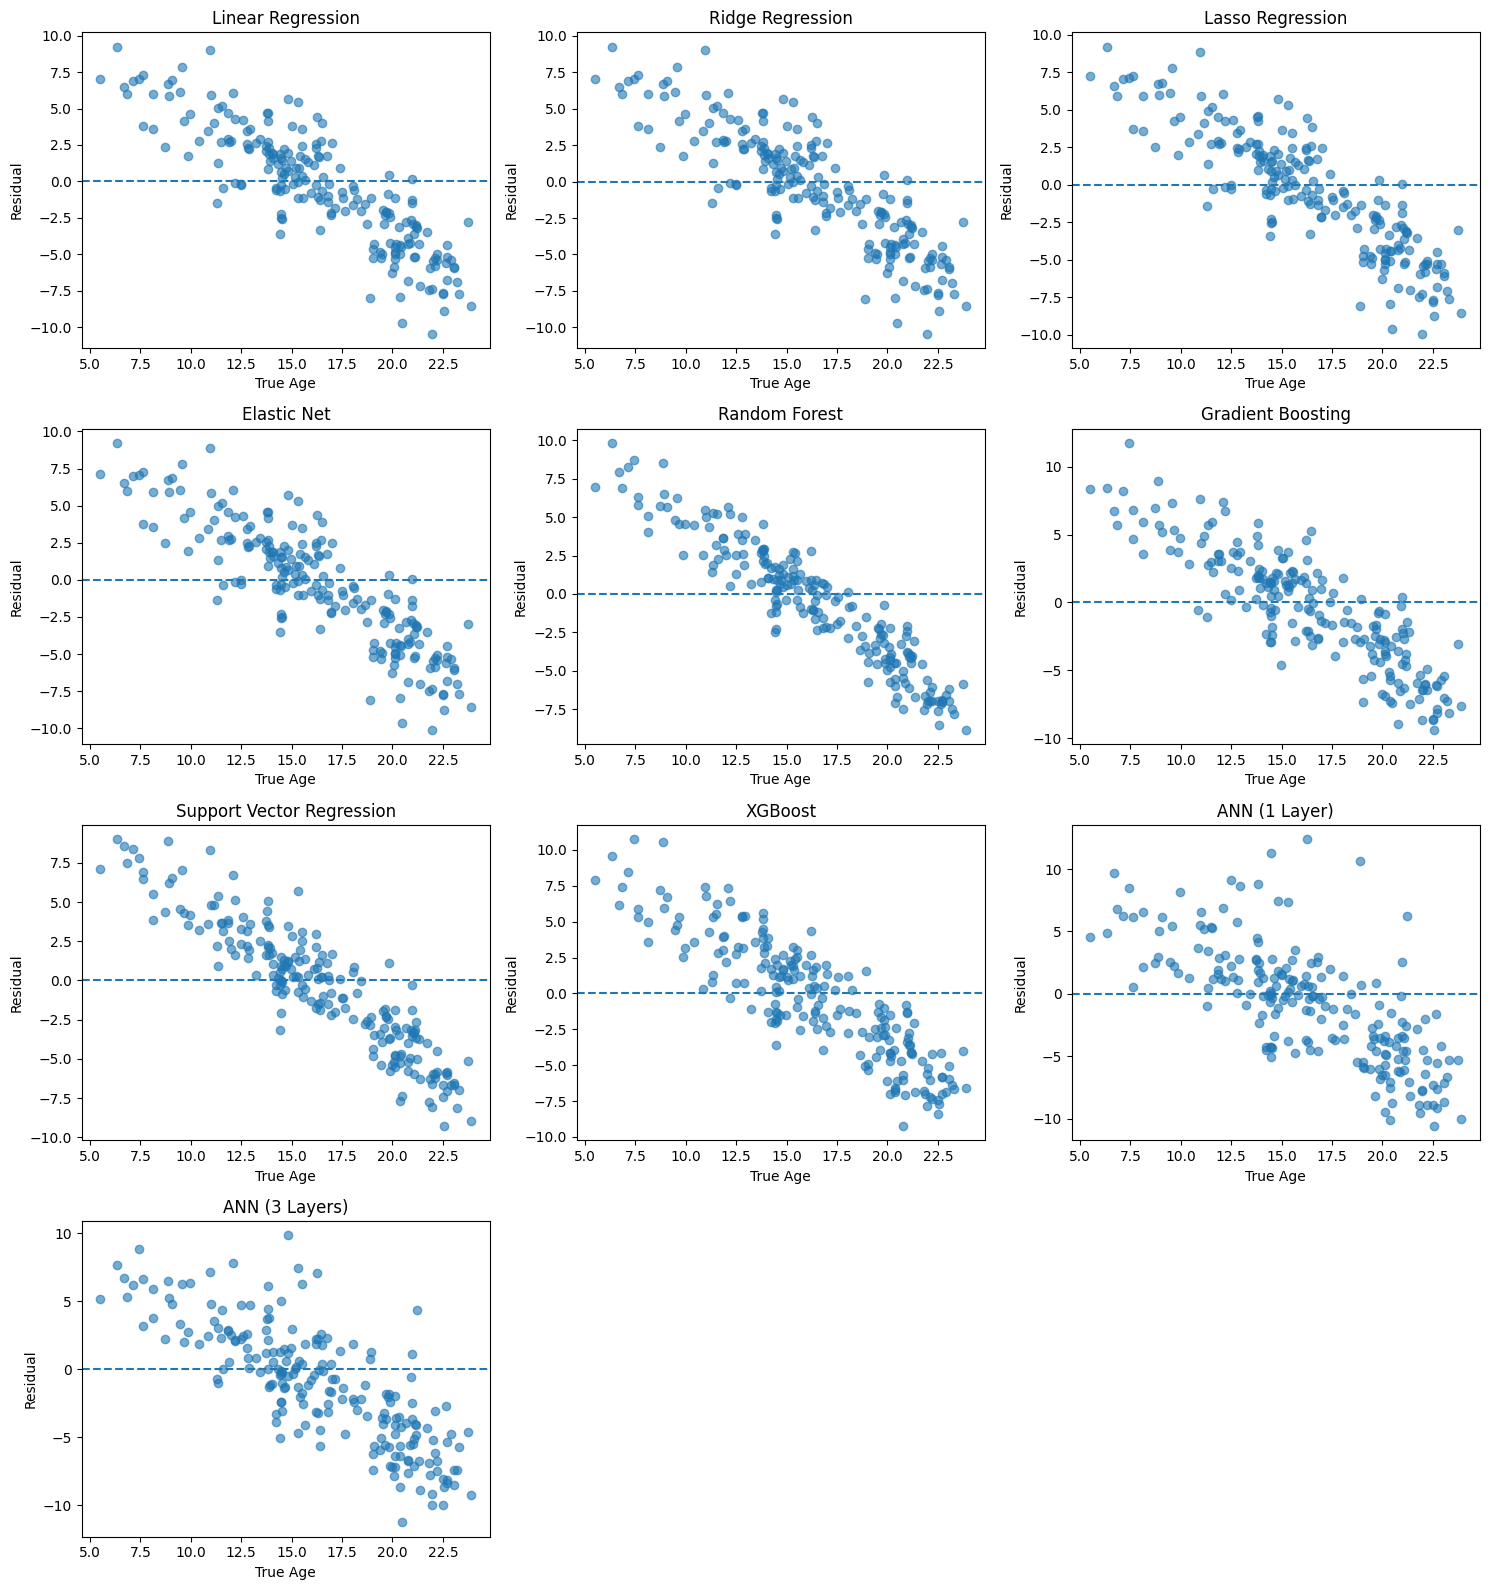


Correlation between Age and Residuals:

Linear Regression: Correlation(Age, Residual) = -0.870
Ridge Regression: Correlation(Age, Residual) = -0.871
Lasso Regression: Correlation(Age, Residual) = -0.877
Elastic Net: Correlation(Age, Residual) = -0.875
Random Forest: Correlation(Age, Residual) = -0.944
Gradient Boosting: Correlation(Age, Residual) = -0.873
Support Vector Regression: Correlation(Age, Residual) = -0.924
XGBoost: Correlation(Age, Residual) = -0.883
ANN (1 Layer): Correlation(Age, Residual) = -0.740
ANN (3 Layers): Correlation(Age, Residual) = -0.809


In [ ]:
import math
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from scipy.stats import pearsonr

# Store Predictions for All Classical Models

model_predictions = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred_model = pipeline.predict(X_test)

    model_predictions[name] = y_pred_model


# Add ANN Predictions
# (Make sure both ANN models already ran)

model_predictions["ANN (1 Layer)"] = y_pred_ann1
model_predictions["ANN (3 Layers)"] = y_pred_ann3


# Residual vs Age Plots (Dynamic Layout)

num_models = len(model_predictions)
cols = 3
rows = math.ceil(num_models / cols)

plt.figure(figsize=(5*cols, 4*rows))

for i, (name, preds) in enumerate(model_predictions.items()):
    plt.subplot(rows, cols, i+1)

    residuals = preds - y_test

    plt.scatter(y_test, residuals, alpha=0.6)
    plt.axhline(0, linestyle='--')
    plt.title(name)
    plt.xlabel("True Age")
    plt.ylabel("Residual")

plt.tight_layout()
plt.show()


# Print Age–Residual Correlation

print("\nCorrelation between Age and Residuals:\n")

for name, preds in model_predictions.items():
    residuals = preds - y_test
    corr, _ = pearsonr(y_test, residuals)
    print(f"{name}: Correlation(Age, Residual) = {corr:.3f}")

**Residual Error vs True Age for ANN & ANN+LR...**

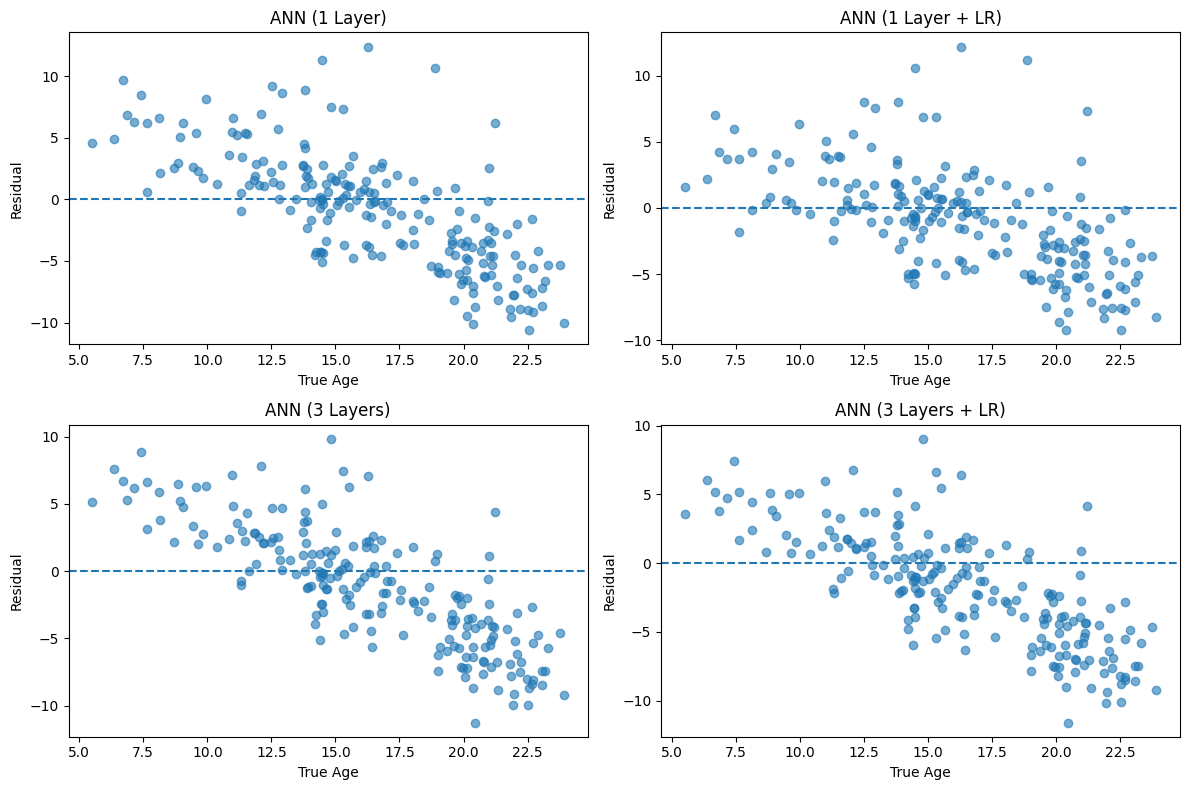


Correlation between Age and Residuals:

ANN (1 Layer): Correlation(Age, Residual) = -0.740
ANN (1 Layer + LR): Correlation(Age, Residual) = -0.601
ANN (3 Layers): Correlation(Age, Residual) = -0.809
ANN (3 Layers + LR): Correlation(Age, Residual) = -0.776


In [ ]:
import math
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

model_predictions = {}

# ONLY ANN Models (with & without LR)

model_predictions["ANN (1 Layer)"] = y_pred_ann1
model_predictions["ANN (1 Layer + LR)"] = y_pred_ann1_LR

model_predictions["ANN (3 Layers)"] = y_pred_ann3
model_predictions["ANN (3 Layers + LR)"] = y_pred_ann3_LR


# Plot

num_models = len(model_predictions)
cols = 2
rows = math.ceil(num_models / cols)

plt.figure(figsize=(6*cols, 4*rows))

for i, (name, preds) in enumerate(model_predictions.items()):
    plt.subplot(rows, cols, i+1)

    residuals = preds - y_test

    plt.scatter(y_test, residuals, alpha=0.6)
    plt.axhline(0, linestyle='--')
    plt.title(name)
    plt.xlabel("True Age")
    plt.ylabel("Residual")

plt.tight_layout()
plt.show()


# Correlation

print("\nCorrelation between Age and Residuals:\n")

for name, preds in model_predictions.items():
    residuals = preds - y_test
    corr, _ = pearsonr(y_test, residuals)
    print(f"{name}: Correlation(Age, Residual) = {corr:.3f}")

**Residual Error vs Predicted Age for all Models...**

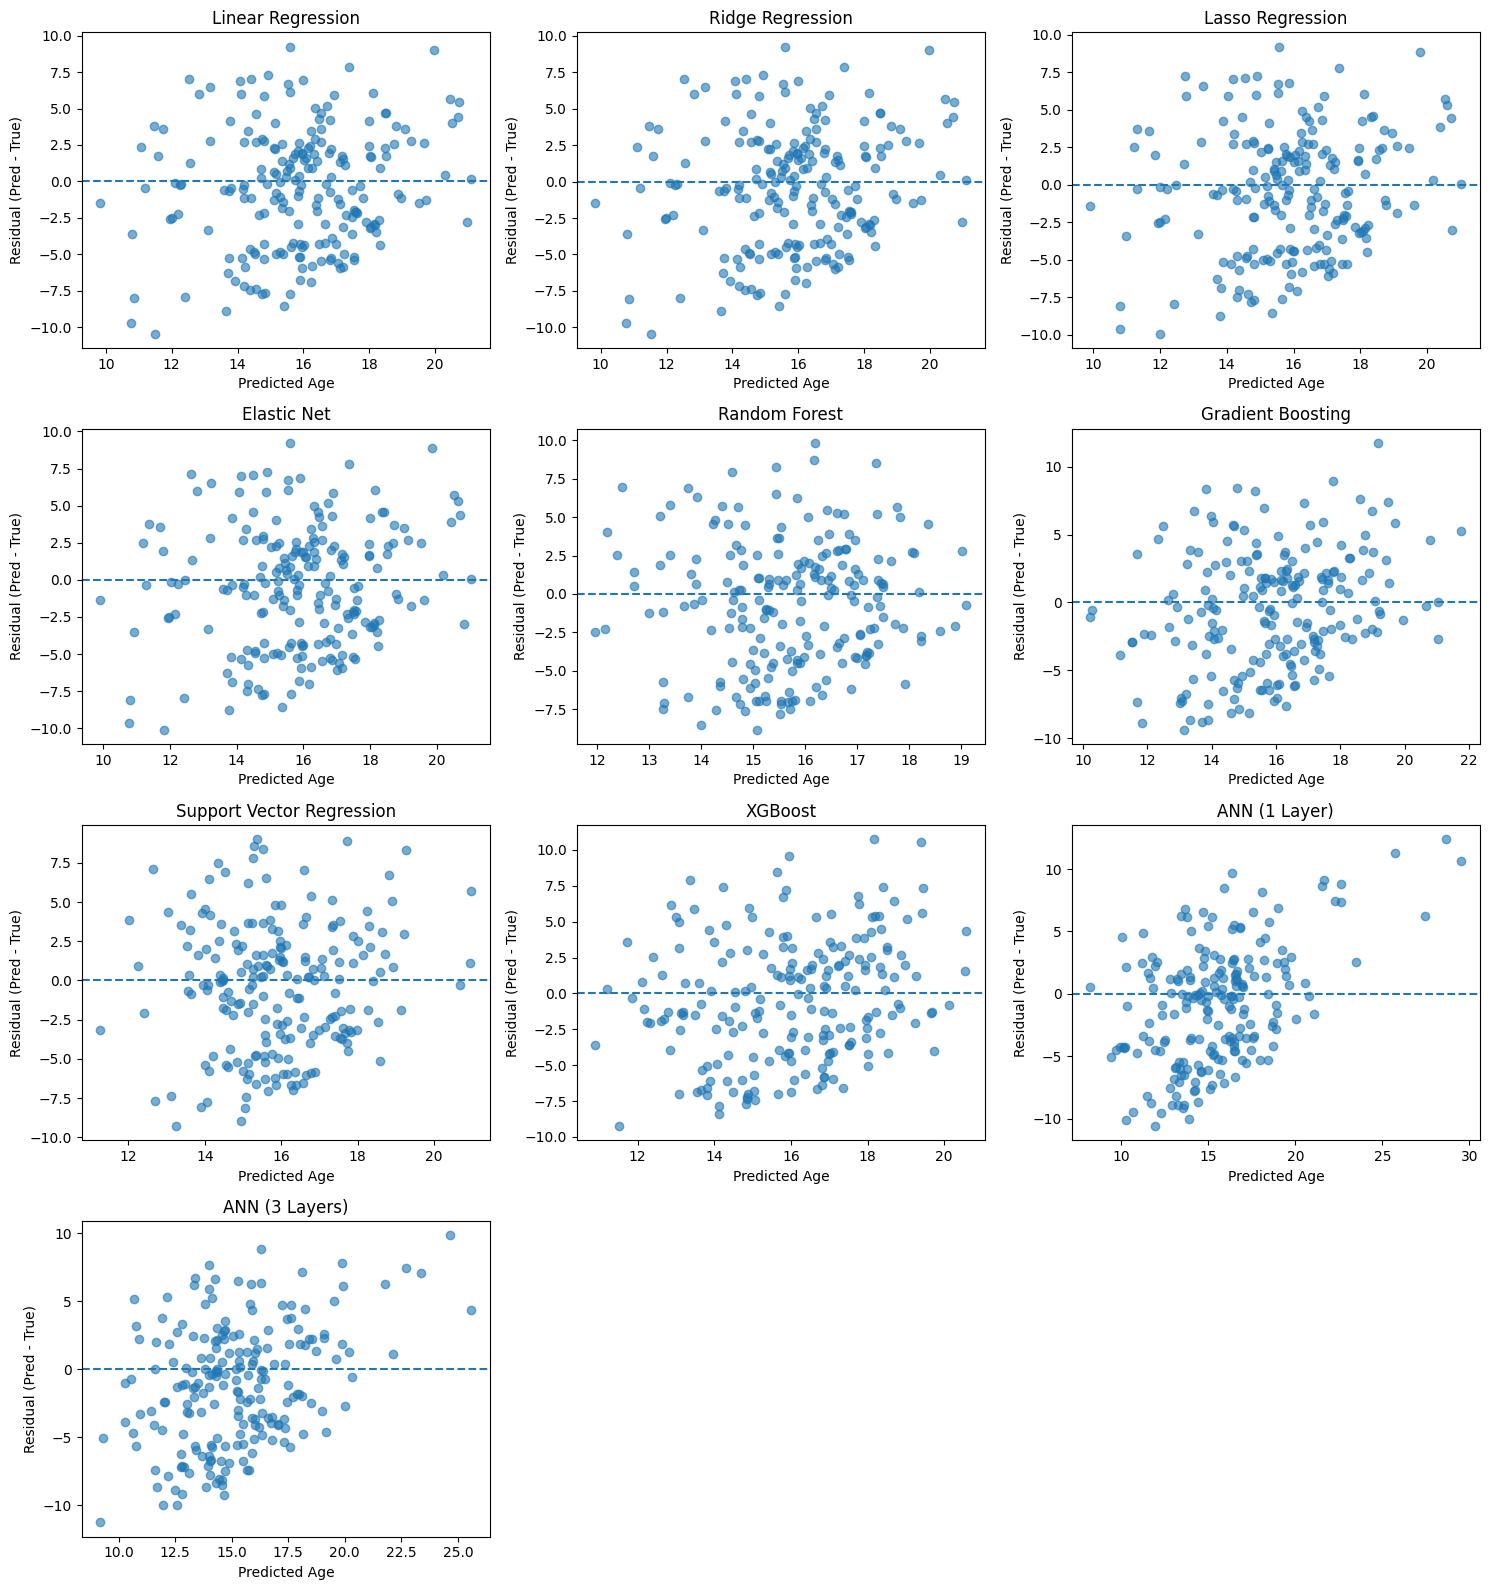


Correlation between Predicted Age and Residuals:

Linear Regression: Corr(Predicted, Residual) = 0.168
Ridge Regression: Corr(Predicted, Residual) = 0.167
Lasso Regression: Corr(Predicted, Residual) = 0.157
Elastic Net: Corr(Predicted, Residual) = 0.160
Random Forest: Corr(Predicted, Residual) = 0.036
Gradient Boosting: Corr(Predicted, Residual) = 0.254
Support Vector Regression: Corr(Predicted, Residual) = 0.080
XGBoost: Corr(Predicted, Residual) = 0.219
ANN (1 Layer): Corr(Predicted, Residual) = 0.477
ANN (3 Layers): Corr(Predicted, Residual) = 0.357


In [ ]:
import math
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from scipy.stats import pearsonr

model_predictions = {}

# Classical Models
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred_model = pipeline.predict(X_test)

    model_predictions[name] = y_pred_model


# ANN Models
model_predictions["ANN (1 Layer)"] = y_pred_ann1
model_predictions["ANN (3 Layers)"] = y_pred_ann3


# Plot: Residual vs Predicted Age

num_models = len(model_predictions)
cols = 3
rows = math.ceil(num_models / cols)

plt.figure(figsize=(5*cols, 4*rows))

for i, (name, preds) in enumerate(model_predictions.items()):
    plt.subplot(rows, cols, i+1)

    residuals = preds - y_test

    # X-axis = Predicted Age
    plt.scatter(preds, residuals, alpha=0.6)

    plt.axhline(0, linestyle='--')
    plt.title(name)
    plt.xlabel("Predicted Age")
    plt.ylabel("Residual (Pred - True)")

plt.tight_layout()
plt.show()


# Correlation (Predicted vs Residual)

print("\nCorrelation between Predicted Age and Residuals:\n")

for name, preds in model_predictions.items():
    residuals = preds - y_test
    corr, _ = pearsonr(preds, residuals)
    print(f"{name}: Corr(Predicted, Residual) = {corr:.3f}")

**Residual Error vs Predicted Age for ANN & ANN+LR...**

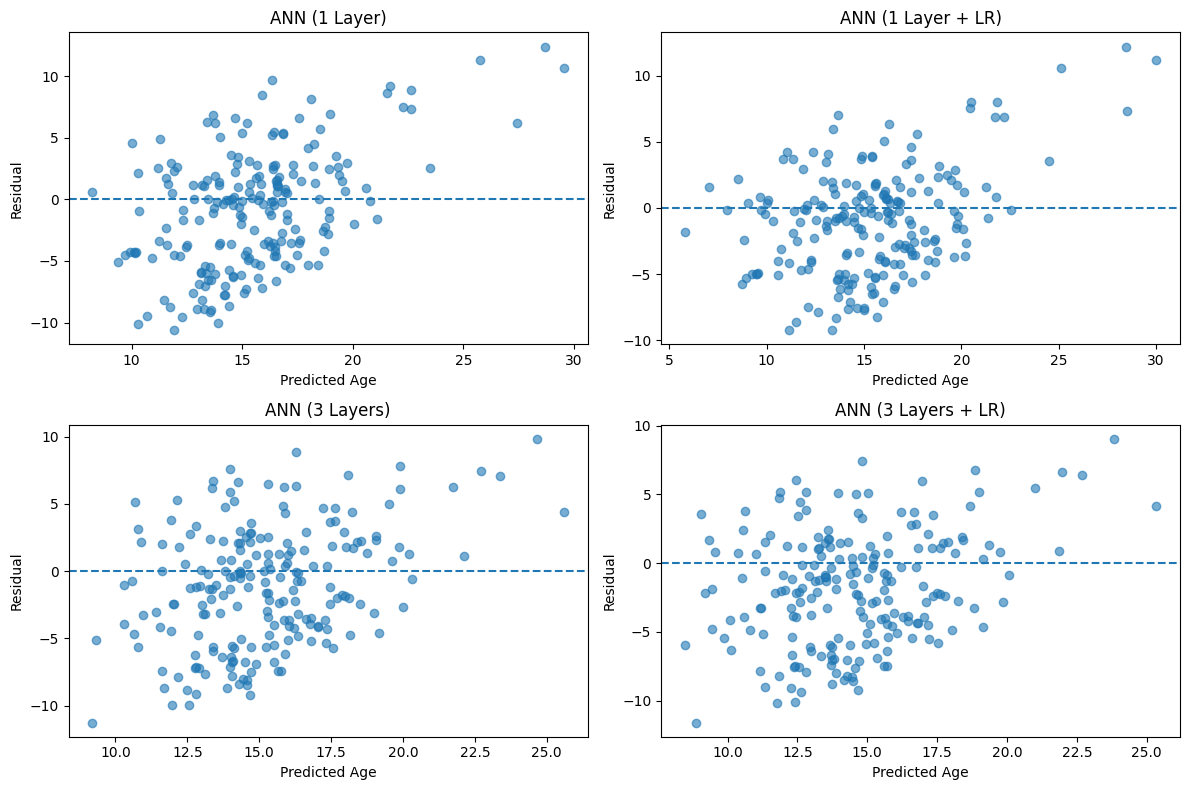


Correlation between Predicted Age and Residuals:

ANN (1 Layer): Corr(Predicted, Residual) = 0.477
ANN (1 Layer + LR): Corr(Predicted, Residual) = 0.381
ANN (3 Layers): Corr(Predicted, Residual) = 0.357
ANN (3 Layers + LR): Corr(Predicted, Residual) = 0.285


In [ ]:
import math
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

model_predictions = {}

model_predictions["ANN (1 Layer)"] = y_pred_ann1
model_predictions["ANN (1 Layer + LR)"] = y_pred_ann1_LR

model_predictions["ANN (3 Layers)"] = y_pred_ann3
model_predictions["ANN (3 Layers + LR)"] = y_pred_ann3_LR


# Plot

cols = 2
rows = 2

plt.figure(figsize=(6*cols, 4*rows))

for i, (name, preds) in enumerate(model_predictions.items()):
    plt.subplot(rows, cols, i+1)

    residuals = preds - y_test

    plt.scatter(preds, residuals, alpha=0.6)

    plt.axhline(0, linestyle='--')
    plt.title(name)
    plt.xlabel("Predicted Age")
    plt.ylabel("Residual")

plt.tight_layout()
plt.show()


# Correlation

print("\nCorrelation between Predicted Age and Residuals:\n")

for name, preds in model_predictions.items():
    residuals = preds - y_test
    corr, _ = pearsonr(preds, residuals)
    print(f"{name}: Corr(Predicted, Residual) = {corr:.3f}")

**Feature Ranking**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.feature_selection import mutual_info_regression

# -----------------------------
FILE_PATH = "/content/cveda_z_smith10.csv"
TARGET_COLUMN = "age"
N_SPLITS = 5
STEP = 5
# -----------------------------

# Load data
df = pd.read_csv(FILE_PATH)
df = df.dropna(subset=[TARGET_COLUMN])

y = df[TARGET_COLUMN]
X = df.drop(columns=["age", "site", "mean_FD", "sub_id"])

# Encode categorical
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Initialize CV
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

mi_total = np.zeros(X.shape[1])

# -----------------------------
# CV Ranking
# -----------------------------
for train_idx, val_idx in kf.split(X):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    mi_scores = mutual_info_regression(X_train, y_train)
    mi_total += mi_scores

# Average importance
mi_avg = mi_total / N_SPLITS
mi_series = pd.Series(mi_avg, index=X.columns)

# Final ranked list
ranked_features = mi_series.sort_values(ascending=False).index.tolist()

# ------------------------------------------------
# Store Top-K feature subsets in dictionary
# ------------------------------------------------
feature_subsets = {}

for k in range(STEP, len(ranked_features)+1, STEP):
    feature_subsets[k] = ranked_features[:k]

# Example access:
# feature_subsets[5]  -> top 5 features
# feature_subsets[10] -> top 10 features

print("Feature subsets stored successfully.")
print("Keys available:", list(feature_subsets.keys()))

Feature subsets stored successfully.
Keys available: [5, 10, 15, 20, 25, 30, 35, 40, 45]


feature subset

In [ ]:
print("Top 5 features:")
for feature in feature_subsets[5]:
    print(feature)

Top 5 features:
visual-lateral_auditory
visual-lateral_default
visual-medial_exec-control
auditory_exec-control
exec-control_fpn-lang


**mututal information**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.inspection import permutation_importance

FILE_PATH = "cveda_z_smith10.csv"
TARGET_COLUMN = "age"
TOP_K = 5
TASK_TYPE = "regression"   # "regression" or "classification"
N_SPLITS = 5

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(FILE_PATH)
df = df.dropna(subset=[TARGET_COLUMN])

y = df[TARGET_COLUMN]
X = df.drop(columns=["age", "site", "mean_FD", "sub_id"])

# -----------------------------
# Encode categorical features
# -----------------------------
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# -----------------------------
# Initialize CV
# -----------------------------
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Containers to accumulate importance
mi_importance_total = np.zeros(X.shape[1])
tree_importance_total = np.zeros(X.shape[1])
perm_importance_total = np.zeros(X.shape[1])

# ======================================================
# Cross-Validation Loop
# ======================================================
for train_index, test_index in kf.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Scale inside fold (prevents leakage)
    scaler = StandardScaler()
    X_train = pd.DataFrame(
        scaler.fit_transform(X_train), columns=X.columns
    )
    X_test = pd.DataFrame(
        scaler.transform(X_test), columns=X.columns
    )

    # -----------------------------
    # 1. Mutual Information
    # -----------------------------
    if TASK_TYPE == "classification":
        mi_scores = mutual_info_classif(X_train, y_train)
    else:
        mi_scores = mutual_info_regression(X_train, y_train)
    mi_importance_total += mi_scores
    # -----------------------------
    # 2. Tree-Based Importance
    # -----------------------------
    if TASK_TYPE == "classification":
        model = RandomForestClassifier(
            n_estimators=300, random_state=42
        )
    else:
        model = RandomForestRegressor(
            n_estimators=300, random_state=42
        )

    model.fit(X_train, y_train)

    tree_importance_total += model.feature_importances_

    # -----------------------------
    # 3. Permutation Importance
    # -----------------------------
    perm_result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    perm_importance_total += perm_result.importances_mean


# ======================================================
# Average Across Folds
# ======================================================
mi_avg = mi_importance_total / N_SPLITS
tree_avg = tree_importance_total / N_SPLITS
perm_avg = perm_importance_total / N_SPLITS

mi_series = pd.Series(mi_avg, index=X.columns)
tree_series = pd.Series(tree_avg, index=X.columns)
perm_series = pd.Series(perm_avg, index=X.columns)

# ======================================================
# Print Top-K
# ======================================================
print("\nTop K Features (Mutual Information - CV Averaged)")
print(mi_series.sort_values(ascending=False).head(TOP_K))

print("\nTop K Features (Tree Importance - CV Averaged)")
print(tree_series.sort_values(ascending=False).head(TOP_K))

print("\nTop K Features (Permutation Importance - CV Averaged)")
print(perm_series.sort_values(ascending=False).head(TOP_K))


Top K Features (Mutual Information - CV Averaged)
visual-lateral_auditory       0.073635
visual-lateral_default        0.056025
visual-medial_exec-control    0.050972
auditory_exec-control         0.046837
exec-control_fpn-lang         0.039072
dtype: float64

Top K Features (Tree Importance - CV Averaged)
default_auditory                0.052928
sensorimotor_auditory           0.048549
visual-lateral_cerebellum       0.040544
visual-occpol_visual-lateral    0.040352
default_sensorimotor            0.030912
dtype: float64

Top K Features (Permutation Importance - CV Averaged)
default_auditory                0.045642
visual-occpol_visual-lateral    0.020086
visual-lateral_cerebellum       0.015385
sensorimotor_auditory           0.012846
auditory_fpn-percep             0.009308
dtype: float64


model training

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet

from xgboost import XGBRegressor

import pandas as pd
import numpy as np

# -----------------------------
# Models
# -----------------------------
models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),

    "SVR": SVR(kernel="rbf"),

    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        verbosity=0
    )
}

# -----------------------------
# Cross Validation Setup
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {model_name: [] for model_name in models}


# ====================================================
# Train on Feature Subsets
# ====================================================
for k, features in feature_subsets.items():

    X_subset = X[features]

    print(f"\nTraining using Top {k} features")

    for model_name, model in models.items():

        # Scaling is critical for SVR + ElasticNet
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        scores = cross_val_score(
            pipeline,
            X_subset,
            y,
            cv=kf,
            scoring="neg_mean_absolute_error"
        )

        mae = -scores.mean()

        results[model_name].append((k, mae))

        print(f"{model_name} → MAE: {mae:.4f}")


# ====================================================
# Convert results to DataFrame
# ====================================================
final_results = {}

for model_name, values in results.items():
    final_results[model_name] = pd.DataFrame(values, columns=["Num_Features", "MAE"])

print("\nTraining completed.")


Training using Top 5 features
RandomForest → MAE: 3.6848
SVR → MAE: 3.6577
ElasticNet → MAE: 3.6504
XGBoost → MAE: 3.8212

Training using Top 10 features
RandomForest → MAE: 3.5588
SVR → MAE: 3.5712
ElasticNet → MAE: 3.5779
XGBoost → MAE: 3.6687

Training using Top 15 features
RandomForest → MAE: 3.5123
SVR → MAE: 3.4779
ElasticNet → MAE: 3.5437
XGBoost → MAE: 3.5207

Training using Top 20 features
RandomForest → MAE: 3.4318
SVR → MAE: 3.3445
ElasticNet → MAE: 3.4644
XGBoost → MAE: 3.4862

Training using Top 25 features
RandomForest → MAE: 3.4071
SVR → MAE: 3.3200
ElasticNet → MAE: 3.4146
XGBoost → MAE: 3.4680

Training using Top 30 features
RandomForest → MAE: 3.3991
SVR → MAE: 3.3265
ElasticNet → MAE: 3.4042
XGBoost → MAE: 3.4712

Training using Top 35 features
RandomForest → MAE: 3.3739
SVR → MAE: 3.3279
ElasticNet → MAE: 3.3722
XGBoost → MAE: 3.3915

Training using Top 40 features
RandomForest → MAE: 3.3598
SVR → MAE: 3.2919
ElasticNet → MAE: 3.3082
XGBoost → MAE: 3.4129

Training

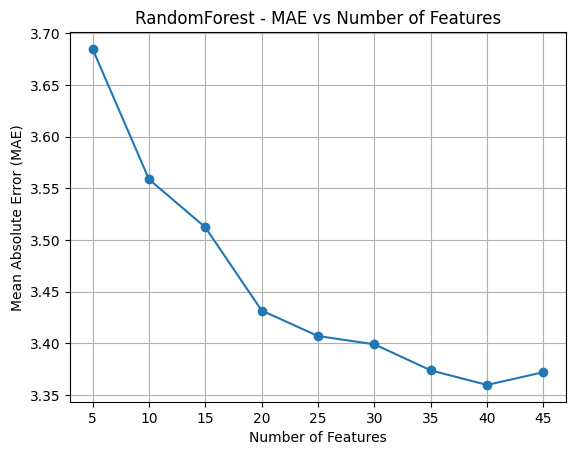

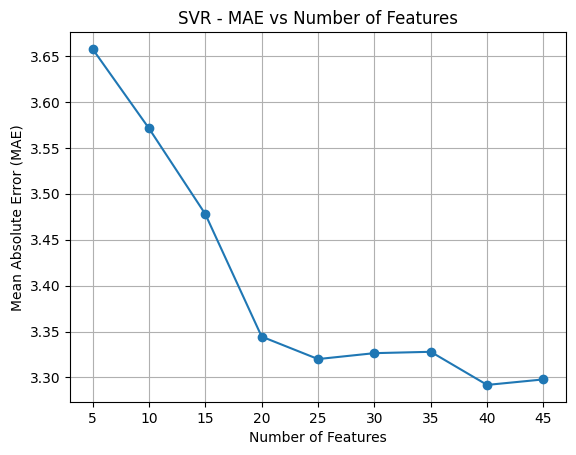

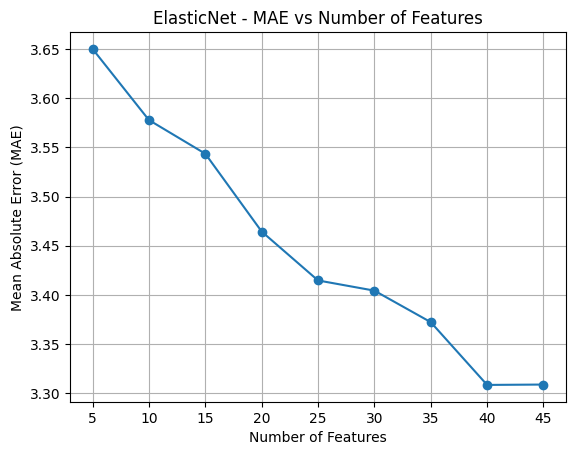

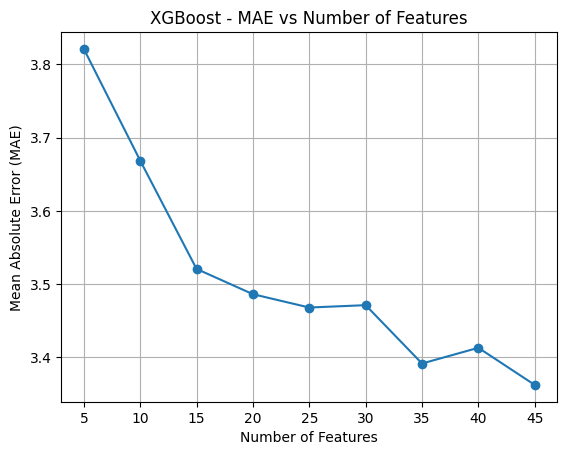

In [ ]:
import matplotlib.pyplot as plt

# Ensure feature counts are sorted
for model_name, df in final_results.items():
    df_sorted = df.sort_values("Num_Features")

    plt.figure()
    plt.plot(df_sorted["Num_Features"], df_sorted["MAE"], marker='o')
    plt.xlabel("Number of Features")
    plt.ylabel("Mean Absolute Error (MAE)")
    plt.title(f"{model_name} - MAE vs Number of Features")
    plt.xticks(range(5, 50, 5))
    plt.grid(True)
    plt.show()